In [1]:

import matplotlib.pyplot as plt
import torch
import torch.utils.data as data

from torch import Tensor
torch.set_default_dtype(torch.float64)


In [2]:
def two_moons(n: int, sigma: float = 1e-1) -> tuple[Tensor, Tensor]:
    theta = 2 * torch.pi * torch.rand(n)
    label = (theta > torch.pi).float()

    x = torch.stack(
        (
            torch.cos(theta) + label - 1 / 2,
            torch.sin(theta) + label / 2 - 1 / 4,
        ),
        axis=-1,
    )

    return torch.normal(x, sigma), label


X, Y = two_moons(200)

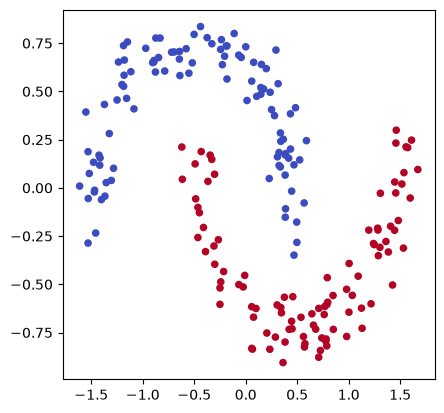

In [3]:
plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)

In [4]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from math import *


In [5]:
# torch.manual_seed(7777)

m, n = X.shape
h = 20  # num. hidden units per layer
k = 1  # num. of output unit


class Model(nn.Module):
    
    def __init__(self):
        super(Model, self).__init__()

        self.feature_map = nn.Sequential(
            nn.Linear(n, h),
            nn.BatchNorm1d(h),
            nn.ReLU(), 
            nn.Linear(h, h), 
            nn.BatchNorm1d(h),
            nn.ReLU()
        )

        self.clf = nn.Linear(h, 1, bias=False)
    
    def forward(self, x):
        x = self.feature_map(x)
        return self.clf(x)
    
    
X_train = X
y_train = Y
    
model = Model()
opt = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

for it in range(5000):
    y_pred = model(X_train).squeeze()
    l = F.binary_cross_entropy_with_logits(y_pred, y_train)
    l.backward()
    opt.step()
    opt.zero_grad()
        
print(f'Loss: {l.item():.3f}')

Loss: 0.006


In [6]:
x1 = torch.linspace(-5, 5, 100)
x2 = torch.linspace(-5, 5, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

X_test = torch.stack((X1.flatten(), X2.flatten()), dim=-1)

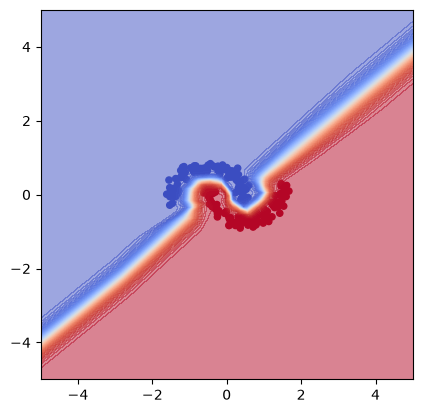

In [7]:
model.eval()

def sigmoid(x):
    return 1/(1+np.exp(-x))

with torch.no_grad():
    model.eval()
    py = sigmoid(model(X_test).squeeze().numpy())
    
conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)

C:\Users\stoennis\AppData\Local\Temp\ipykernel_20160\2433527366.py:56: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)


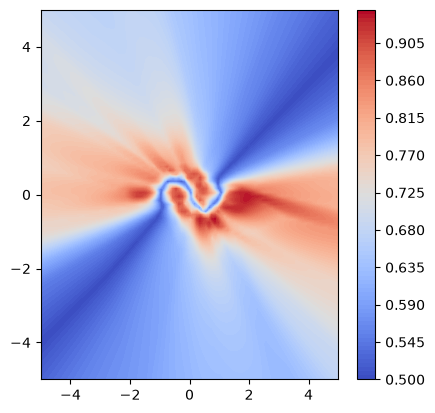

In [8]:
# Exact Hessian using PyTorch's autograd. Credits due to Felix Dangel.
from hessian import exact_hessian


W = list(model.parameters())[-1]
shape_W = W.shape

w_map = W.view(-1).data.numpy()


def neg_log_posterior(var0):
    # Negative-log-likelihood
    nll = F.binary_cross_entropy_with_logits(model(X_train).squeeze(), y_train, reduction='sum')
    # Negative-log-prior
    nlp = 1/2 * W.flatten() @ (1/var0 * torch.eye(W.numel())) @ W.flatten()
    
    return nll + nlp


def get_covariance(var0):
    # Outputs the inverse-Hessian of the negative-log-posterior at the MAP estimate
    # This is the posterior covariance
    loss = neg_log_posterior(var0)
    Lambda = exact_hessian(loss, [W])  # The Hessian of the negative log-posterior
    Sigma = torch.inverse(Lambda).detach().numpy()
    
    return Sigma


@torch.no_grad()
def predict(x, Sigma):    
    phi = model.feature_map(x).numpy()  # Feature vector of x
    m = phi @ w_map  # MAP prediction

    # "Moderate" the MAP prediction using the variance (see MacKay 1992 "Evidence Framework ...")
    # This is an approximation of the expected sigmoid (the so-called "probit approximation")
    v = np.diag(phi @ Sigma @ phi.T)
    py = sigmoid(m/np.sqrt(1 + pi/8 * v))
        
    return py


# The weight decay used for training is the Gaussian prior's precision
# Here we work in term of variance, which is just 1/precision.
var0 = 1/5e-4 

# Get the posterior covariance and make prediction
Sigma = get_covariance(var0)
py = predict(X_test, Sigma)

conf = np.maximum(py, 1-py)

plt.figure(figsize=(4.8, 4.8))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=20)
# plt.contourf(X1, X2, py.reshape(X1.shape), levels=100, cmap="coolwarm", alpha=0.5)
plt.contourf(X1, X2, conf.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()


In [9]:
import math

import pyro

import pyro.distributions as dist
from pyro.infer import SVI, Predictive, Trace_ELBO
from pyro.infer.autoguide import AutoLaplaceApproximation, init_to_value

from dataclasses import dataclass

c:\Users\stoennis\Desktop\UQHM\github\last_layer_laplace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Full Pyro model: MLE features + Laplace on the last layer

Everything is trained inside Pyro here. `feature_map` holds plain
`nn.Parameter`s, which `PyroModule` registers in the param store, so SVI fits
them by maximum likelihood; `w` is the only latent site, so
`AutoLaplaceApproximation` puts a Gaussian on the last layer only.

Two things to get right:

* `prior_scale` is a **standard deviation**. The weight decay is the prior
  *precision*, so `prior_scale = sqrt(var0)`, not `var0`.
* `logits = (phi @ w.unsqueeze(-1)).squeeze(-1)` rather than `phi @ w`, so the
  shapes still work when `Predictive` adds a leading sample dimension.

In [10]:
class BayesianMLP(pyro.nn.PyroModule):
    def __init__(self, n, h, prior_scale=1.0):
        super().__init__()
        self.h = h
        self.feature_map = nn.Sequential(
            nn.Linear(n, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Linear(h, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
        )
        self.prior_scale = prior_scale
        self._guide = AutoLaplaceApproximation(self.model, init_loc_fn=init_to_value(values={"w": torch.rand(h)*-2*h**-2 + h**-2}))

    def model(self, x, y=None):
        phi = self.feature_map(x)
        w = pyro.sample(
            "w", dist.Normal(torch.zeros(self.h), self.prior_scale).to_event(1)
        )
        logits = (phi @ w.unsqueeze(-1)).squeeze(-1)   # (..., N)
        pyro.deterministic("logits", logits)
        with pyro.plate("data", x.shape[0]):
            pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    def guide(self, x, y=None):
        return self._guide(x, y)

In [11]:
LOG_EVERY = 1000
N_STEPS = 10000

In [ ]:
from pyro.optim import ClippedAdam, SGD
from pyro.infer import MCMC, NUTS
pyro.clear_param_store()
# torch.manual_seed(7777)

N_STEPS = 5000
initial_lr = 1e-3          # 1e-3 leaves this badly undertrained after 10k steps
lrd = 0.1 ** (1 / N_STEPS)
var0 = 1/5e-100                 # prior variance of the last layer weights


BNN = BayesianMLP(n=n, h=h, prior_scale=math.sqrt(var0))   # scale, not variance!
BNN.feature_map.train()                                    # BatchNorm uses batch stats

nuts = NUTS(
    model=BNN.model,
    init_strategy=init_to_value(values={"w": torch.rand(h)*-2*h**-2 + h**-2}),
    )

mcmc = MCMC(
    nuts,
    num_chains=1,
    num_samples=1500,
    warmup_steps=500,
    # mp_context="spawn",
)
mcmc.run(X_train,y_train)

Warmup:   0%|          | 0/2000 [00:00, ?it/s]

AttributeError: 'int' object has no attribute '_warmup_steps'

In [383]:

losses = []
for step in range(1, N_STEPS + 1):
    losses.append(svi.step(X_train, y_train))
    # if step % LOG_EVERY == 0:
    #     print(f"    step {step:>6}/{N_STEPS}   -log p(w, D): {losses[-1]:>12.4f}")

In [384]:
store = pyro.get_param_store()
for k in sorted(store.keys()):
    v = store[k]
    print(f"{k:28s} {tuple(v.shape)}  |v| mean {v.abs().mean():.4f}")

_guide.loc                   (20,)  |v| mean 3.5947
feature_map$$$0.bias         (20,)  |v| mean 0.3202
feature_map$$$0.weight       (20, 2)  |v| mean 0.4071
feature_map$$$1.bias         (20,)  |v| mean 0.0000
feature_map$$$1.weight       (20,)  |v| mean 1.0000
feature_map$$$3.bias         (20,)  |v| mean 0.1477
feature_map$$$3.weight       (20, 20)  |v| mean 0.1147
feature_map$$$4.bias         (20,)  |v| mean 0.0000
feature_map$$$4.weight       (20,)  |v| mean 1.0000


Text(0, 0.5, '$-\\log p(w, D)$')

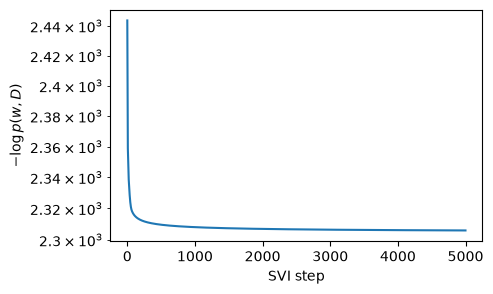

In [385]:
plt.figure(figsize=(4.8, 3))
plt.plot(losses)
plt.yscale("log")
plt.xlabel("SVI step"); plt.ylabel(r"$-\log p(w, D)$")

### Switch BatchNorm to eval mode *before* the Laplace step

This is the bug that made the $[-15,15]^2$ and $[-5,5]^2$ plots identical. In
train mode `BatchNorm1d` normalises by the statistics of *the batch it is
currently given*, so the test grid gets standardised to zero mean / unit
variance whatever its extent — both grids collapse onto the same standardised
inputs and the network cannot tell them apart. `eval()` switches to the running
statistics accumulated during training, which is what makes absolute input
coordinates mean anything at test time.

It also has to happen before `laplace_approximation`, so the Hessian is taken
through the same fixed feature map that prediction will use.

In [400]:
BNN.feature_map.eval()
for p in BNN.feature_map.parameters():
    p.requires_grad_(False)

with torch.no_grad():
    w_hat = pyro.param("_guide.loc")
    acc = (((BNN.feature_map(X_train) @ w_hat) > 0).double() == y_train).double().mean()
print(f"train accuracy: {acc:.3f}")

guide = BNN._guide.laplace_approximation(X_train, y_train)
posterior = guide.get_posterior()
loc, Sigma = posterior.mean, posterior.covariance_matrix
print("posterior std (first 5):", posterior.stddev[:5].numpy().round(3))

train accuracy: 1.000
posterior std (first 5): [47.882 78.059 89.577 48.282 63.735]


In [404]:
print(Sigma)
print(type(Sigma))

tensor([[ 2.2927e+03, -2.3244e+03,  1.0654e+03,  4.2876e+02, -8.7592e+02,
         -5.8749e+02, -5.0630e+02,  8.8965e+01, -1.1792e+03,  7.8700e+02,
         -7.1688e+02, -3.5960e+02,  5.2609e+02,  9.2052e+02,  7.3637e+02,
         -6.4413e+02,  2.4278e+02,  8.0293e+02,  1.7799e+03, -2.9656e+03],
        [-2.3244e+03,  6.0932e+03, -5.6739e+03,  1.0020e+03,  3.4036e+03,
          4.0554e+02,  3.6308e+02, -6.2765e+02,  1.4637e+03,  1.7522e+03,
          2.2872e+02, -4.5892e+02, -7.6134e+02, -3.9488e+03, -6.3352e+02,
          3.5280e+02, -2.0285e+03, -2.2124e+03, -1.4545e+03,  6.0945e+03],
        [ 1.0654e+03, -5.6739e+03,  8.0241e+03, -1.3204e+03, -4.7908e+03,
         -8.0283e+01, -4.7516e+02,  1.0581e+03, -7.7170e+02, -2.5711e+03,
         -9.0181e+02,  4.4785e+02,  9.3539e+02,  3.3057e+03,  1.5349e+01,
          2.0542e+02,  4.1462e+03,  3.5655e+03,  6.3984e+01, -7.1638e+03],
        [ 4.2876e+02,  1.0020e+03, -1.3204e+03,  2.3312e+03, -5.1166e+02,
         -8.4994e+02, -1.0779e+03, 

### Predict on both grids

They should now look clearly different: outside the data the Laplace posterior
pulls the probability back toward 0.5.

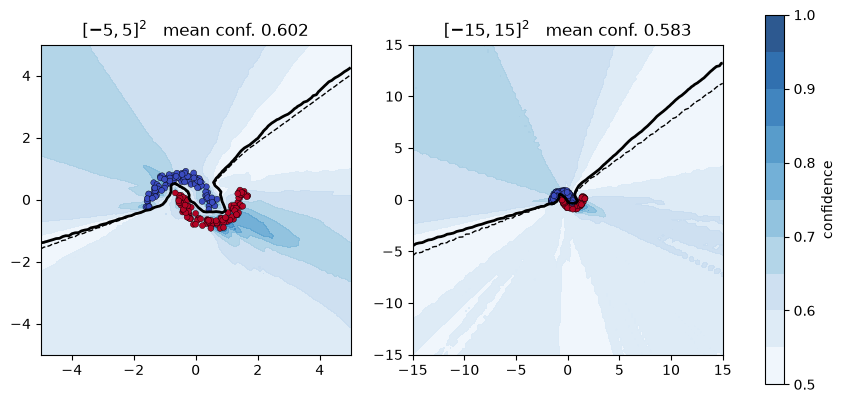

In [387]:
predictive = Predictive(BNN.model, guide=guide, num_samples=1000,
                        return_sites=("logits",))


def grid(lo, hi, N=100):
    t = torch.linspace(lo, hi, N)
    A, B = torch.meshgrid(t, t, indexing="ij")
    return A, B, torch.stack((A.flatten(), B.flatten()), dim=-1)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, (lo, hi) in zip(axes, ((-5, 5), (-15, 15))):
    A, B, Xt = grid(lo, hi)

    p = predictive(Xt, None)["logits"].sigmoid().mean(0).detach().reshape(A.shape)
    with torch.no_grad():
        p_map = (BNN.feature_map(Xt) @ loc).sigmoid().reshape(A.shape)

    conf = torch.maximum(p, 1 - p)
    im = ax.contourf(A, B, conf, levels=np.arange(0.5, 1.01, 0.05),
                     cmap="Blues", vmin=0.5, vmax=1.0, alpha=0.85)
    ax.contour(A, B, p, levels=[0.5], colors="black", linewidths=2)
    ax.contour(A, B, p_map, levels=[0.5], colors="black", linewidths=1,
               linestyles="dashed")
    ax.scatter(X[:, 0], X[:, 1], c=Y, cmap="coolwarm", s=18,
               edgecolors="k", linewidths=0.3)
    ax.set_title(f"$[{lo},{hi}]^2$   mean conf. {conf.mean():.3f}")
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="confidence")

In [388]:
X1, X2, X_test = grid(-5, 5)

p = predictive(X_test, None)["logits"].sigmoid().mean(0).detach().reshape(X1.shape)
with torch.no_grad():
    p_map = (BNN.feature_map(X_test) @ loc).sigmoid().reshape(X1.shape)

conf = torch.maximum(p, 1 - p)

phi = BNN.feature_map(X_test).detach().numpy()
m = phi @ loc.detach().numpy()
Lambda = posterior.covariance_matrix.detach().numpy()
Sigma = np.linalg.inv(Lambda)
v = np.diag(phi @ Lambda @ phi.T)
py = sigmoid(m/np.sqrt(1 + pi/8 * v))
p_map_ll = py
conf_map = np.maximum(p_map_ll, 1 - p_map_ll)


C:\Users\stoennis\AppData\Local\Temp\ipykernel_12976\303920402.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf, levels=100, cmap='coolwarm', linewidths=2)


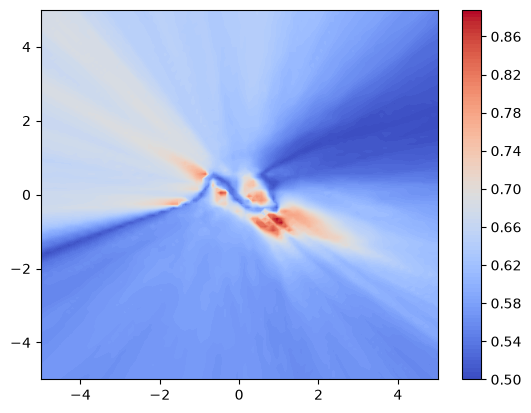

In [389]:


# plt.contourf(X1, X2, p, levels=100, cmap='coolwarm', linewidths=2)
plt.contourf(X1, X2, conf, levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()

C:\Users\stoennis\AppData\Local\Temp\ipykernel_12976\203417728.py:2: UserWarning: linewidths is ignored by contourf
  plt.contourf(X1, X2, conf_map.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)


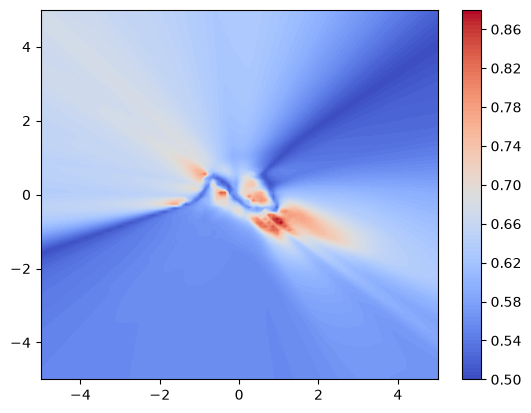

In [390]:

# plt.contourf(X1, X2, p, levels=100, cmap='coolwarm', linewidths=2)
plt.contourf(X1, X2, conf_map.reshape(X1.shape), levels=100, cmap='coolwarm', linewidths=2)
plt.colorbar()